In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import polars as pl
import polars.selectors as selectors

from src.config import RAW_TRAIN_DATA_DIR, TARGET_PATH, USED_DATASET_PATH

In [3]:
data_lazy = (
    pl.scan_parquet(RAW_TRAIN_DATA_DIR)
    .with_columns(
        selectors.integer().exclude("id").cast(pl.Int16),
        pl.col("id").cast(pl.Int32),
        selectors.float().cast(pl.Float16),
    )
)

target_lazy = pl.scan_csv(
    TARGET_PATH,
    schema_overrides={"id": pl.Int32, "flag": pl.Int8},
)

data = (
    data_lazy
    .join(target_lazy, on="id", how="inner")
    .collect(engine="streaming")
    .sample(n=2_000_000, seed=0)
)

In [4]:
data = data.drop(["pre_fterm", "pre_till_fclose", "fclose_flag"])

- `pre_fterm`: True duration. Known only if the loan is already closed → leakage.
- `pre_till_fclose`:Remaining days until the true end. Needs to know the real closure date → leakage.
- `fclose_flag`: Indicates if the loan is already closed at the collect.

**Decision:** Drop those columns

In [5]:
data.write_parquet(USED_DATASET_PATH)

# EXPLORATORY DATA ANALYSIS

## OVERVIEW

- target: `flag`

Shape: 2 000 000, 62

In [6]:
data.shape

(2000000, 59)

## Description

In [7]:
data.describe()

statistic,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,flag
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.5463e6,7.046618,9.3642615,8.228435,8.369211,7.144697,9.678863,2.3631085,2.996881,0.0,2.0051395,4.614454,5.974737,15.872856,5.0013265,3.999875,8.0032995,0.918917,0.832236,0.957353,0.9754995,0.975994,13.828763,2.2119535,15.684691,0.697859,0.9301325,0.855825,0.1642695,0.379742,0.518915,0.649193,0.7816835,0.9140375,1.07538,1.228759,1.342804,1.4503705,1.577855,2.708788,1.8428575,1.9652135,2.028475,2.077525,2.12204,2.164079,2.2083645,2.2491475,3.2834015,2.315402,2.3469115,2.3809675,3.529793,1.034096,2.6933045,3.5196575,1.0016495,0.1490555,0.033523
"""std""",867845.314309,5.392957,5.777472,4.712894,5.325203,5.152573,5.827232,1.310066,0.711151,0.0,0.282183,3.307399,0.387858,1.175275,0.072455,0.019157,0.147928,0.272963,0.373657,0.20206,0.154597,0.153068,4.387031,0.858599,3.984926,0.459186,0.254924,0.351267,0.629298,0.932699,1.084132,1.191476,1.278511,1.346943,1.408817,1.448447,1.467082,1.476748,1.477731,1.466919,1.443518,1.409873,1.388257,1.369294,1.350352,1.330754,1.308464,1.286111,1.266208,1.246395,1.225816,1.202358,1.080884,0.304605,0.499641,1.037207,0.048123,0.356143,0.179998
"""min""",1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",796357.0,3.0,4.0,4.0,4.0,2.0,5.0,2.0,3.0,0.0,2.0,2.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,15.0,2.0,17.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,3.0,3.0,3.0,4.0,1.0,2.0,3.0,1.0,0.0,0.0
"""50%""",1.569309e6,6.0,9.0,9.0,8.0,7.0,10.0,2.0,3.0,0.0,2.0,4.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,16.0,2.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
"""75%""",2.304877e6,10.0,14.0,12.0,14.0,12.0,15.0,2.0,3.0,0.0,2.0,7.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,16.0,2.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
"""max""",2.999997e6,57.0,19.0,17.0,17.0,16.0,19.0,6.0,5.0,0.0,3.0,13.0,16.0,19.0,9.0,4.0,19.0,1.0,1.0,1.0,1.0,1.0,19.0,19.0,19.0,1.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,6.0,6.0,7.0,3.0,1.0,1.0

In [8]:
data.glimpse()

Rows: 2000000
Columns: 59
$ id                            <i32> 2992589, 688188, 614343, 6391, 1014646, 53024, 2081272, 2046773, 2882224, 219338
$ rn                            <i16> 23, 2, 14, 4, 2, 10, 6, 2, 7, 13
$ pre_since_opened              <i16> 3, 8, 9, 4, 6, 1, 13, 16, 14, 11
$ pre_since_confirmed           <i16> 9, 16, 6, 1, 6, 2, 4, 4, 9, 5
$ pre_pterm                     <i16> 6, 4, 12, 17, 4, 16, 7, 17, 4, 7
$ pre_till_pclose               <i16> 0, 1, 12, 2, 1, 7, 13, 9, 1, 11
$ pre_loans_credit_limit        <i16> 8, 13, 10, 0, 17, 10, 5, 12, 17, 3
$ pre_loans_next_pay_summ       <i16> 2, 2, 1, 2, 1, 4, 2, 2, 6, 2
$ pre_loans_outstanding         <i16> 2, 3, 3, 3, 2, 3, 3, 3, 3, 3
$ pre_loans_total_overdue       <i16> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ pre_loans_max_overdue_sum     <i16> 2, 2, 2, 2, 3, 2, 2, 2, 2, 2
$ pre_loans_credit_cost_rate    <i16> 1, 4, 8, 1, 5, 7, 2, 4, 7, 0
$ pre_loans5                    <i16> 6, 6, 6, 6, 6, 6, 6, 6, 6, 6
$ pre_loans530               

## Target distribution
- 0: 96.637%
- 1: 3.363%

In [9]:
target_dist = data.select(
    [
        (pl.col("flag").eq(0).sum() / pl.col("flag").len()).alias("0 flag"),
        (pl.col("flag").eq(1).sum() / pl.col("flag").len()).alias("1 flag"),
    ]
)

target_dist

0 flag,1 flag
f64,f64
0.966477,0.033523


## Missing value

No missing values

In [10]:
missing_dataset = data.select(
    (pl.all().exclude(["id", "flag"]).is_nan().sum() / len(data))
)
missing_dataset

rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data visualization

In [11]:
categorical_features = [f"enc_paym_{i}" for i in range(25)]
categorical_features.extend(
    [
        "is_zero_loans5",
        "is_zero_loans530",
        "is_zero_loans3060",
        "is_zero_loans6090",
        "is_zero_loans90",
        "is_zero_util",
        "is_zero_over2limit",
        "is_zero_maxover2limit",
        "enc_loans_account_holder_type",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "enc_loans_account_cur",
        "pclose_flag",
    ]
)

In [12]:
numerical_features = [
    "rn",
    "pre_since_opened",
    "pre_since_confirmed",
    "pre_pterm",
    "pre_till_pclose",
    "pre_loans_credit_limit",
    "pre_loans_next_pay_summ",
    "pre_loans_outstanding",
    "pre_loans_total_overdue",
    "pre_loans_max_overdue_sum",
    "pre_loans_credit_cost_rate"
]

In [16]:
def feature_distribution(df: pd.DataFrame, features: list, categorical: bool):
    df = df.select(
        pl.col(features)
    ).to_pandas()

    if categorical:
        for feature in features:
            plt.figure(figsize=(10, 5))
            plt.title(feature)
            sb.countplot(data=df, x=feature)
            plt.xticks(rotation=45)
            plt.show()
    else:
        for feature in features:
            plt.figure(figsize=(10, 5))
            plt.title(feature)
            sb.histplot(df[feature], kde=True)
            plt.show()


### Numerical features
- The `rn` seems show me that the more the loan is older the more we have customers
- the `pre_since_confirmed` seems have a main value
- `pre_pterm`: has 2 main values (maybe the client prefer theses durations?)
- `pre_till_pclose`: most customers seem closed her loan at a crtain time before the planed closure
- `pre_till_fclose`: has also a main value occurences
- `pre_loans_credit_cost_rate`: 2 main values occur
- `pre_loans_next_pay_summ` and `pre_loans_outstanding`, `pre_loans_total_overdue` seem constraint between a few values(Is it normal or another thing?)
- `pre_loans_credit_cost_rate`: has 2 predominant values
- `pre_loans_max_overdue_sum` is not pertinent we must have to drop it

**Observations:** Some features seem restraint in a few values. If it's a standard we can try to convert it into categorical value, and it see,s have a lot of outlier. We can have to manage that(winsorizer or robustscaler).

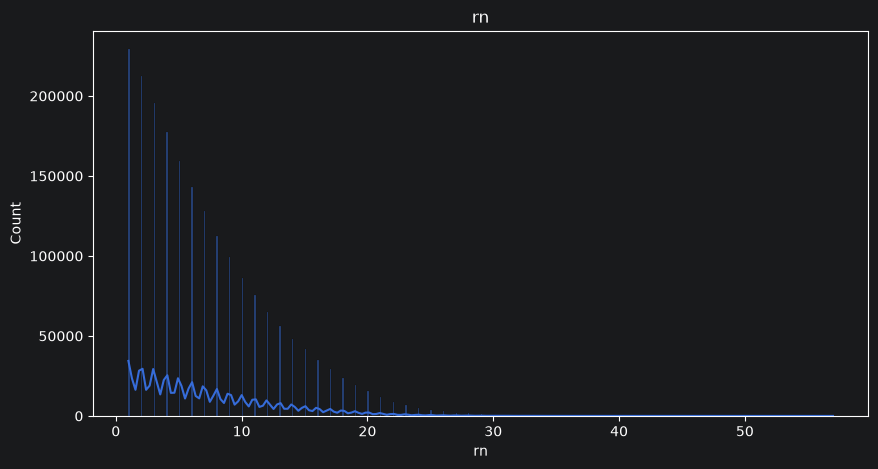

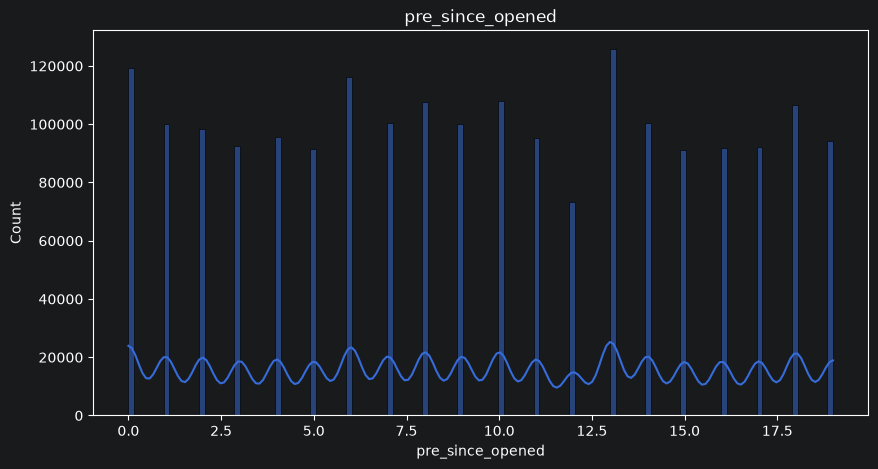

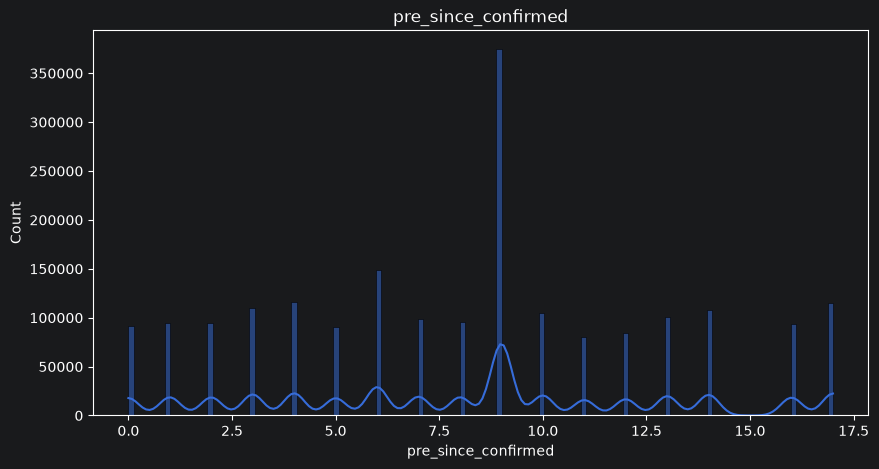

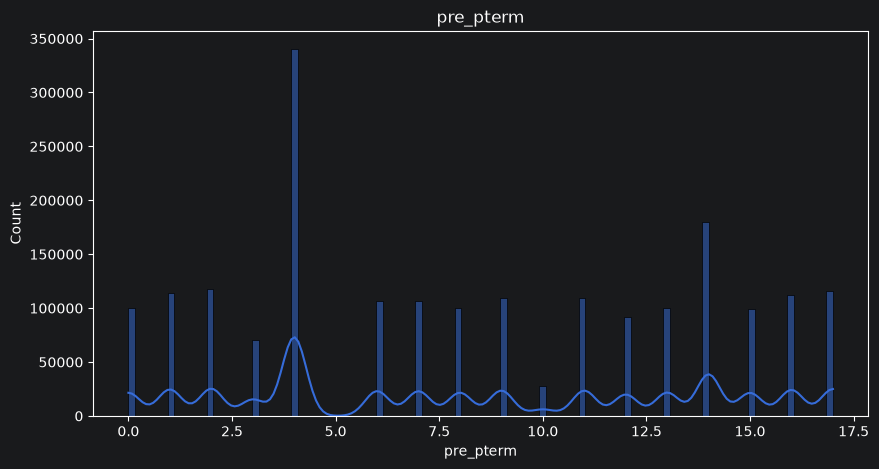

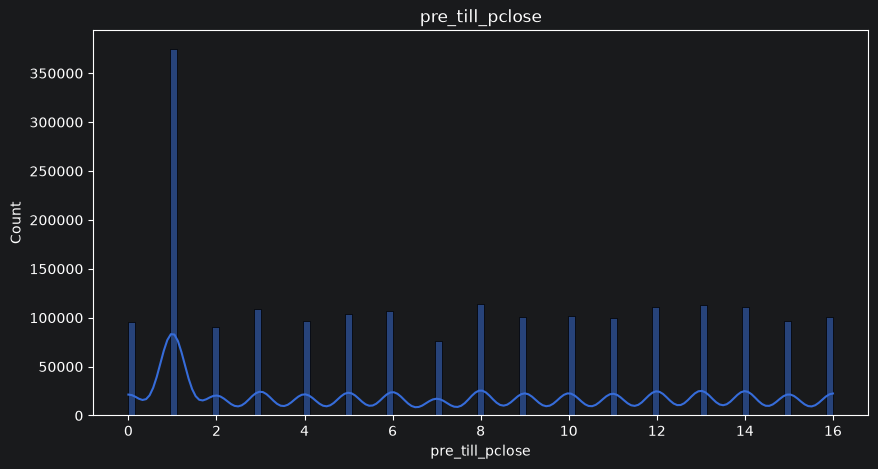

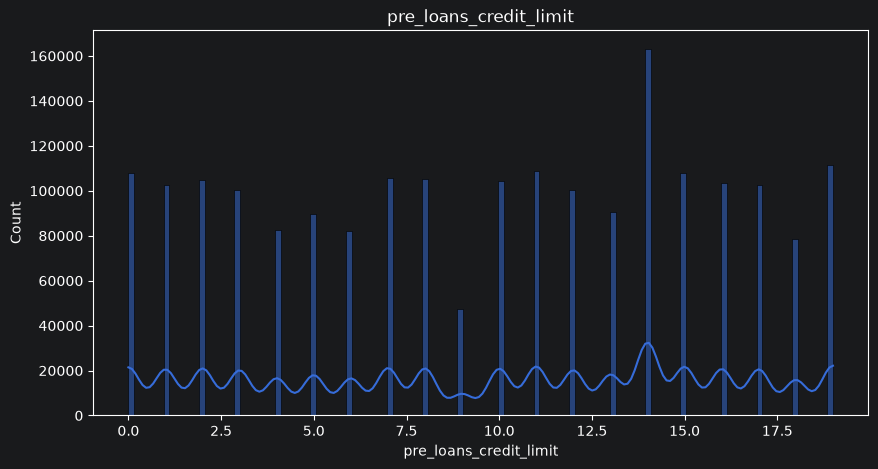

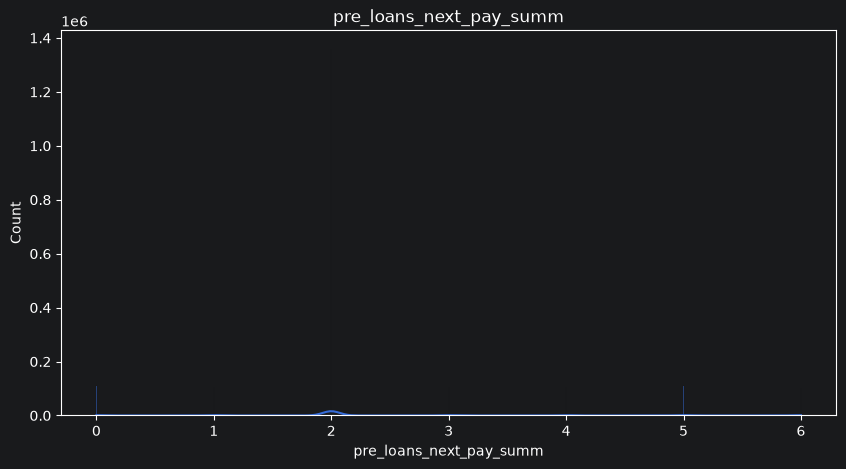

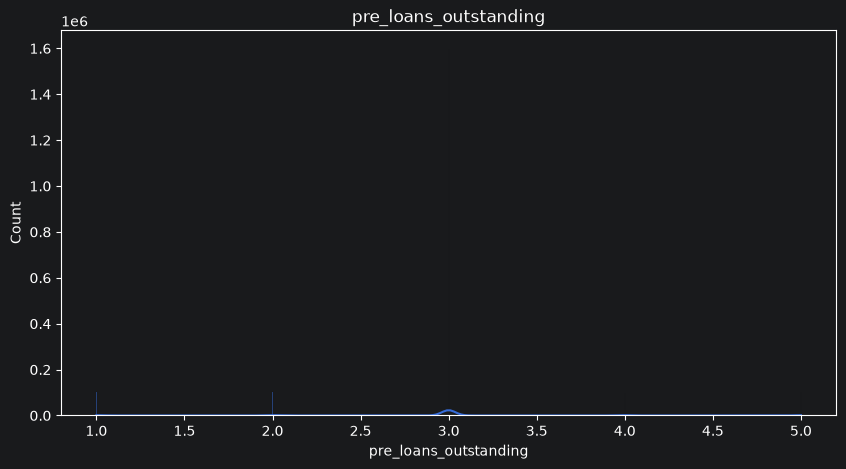

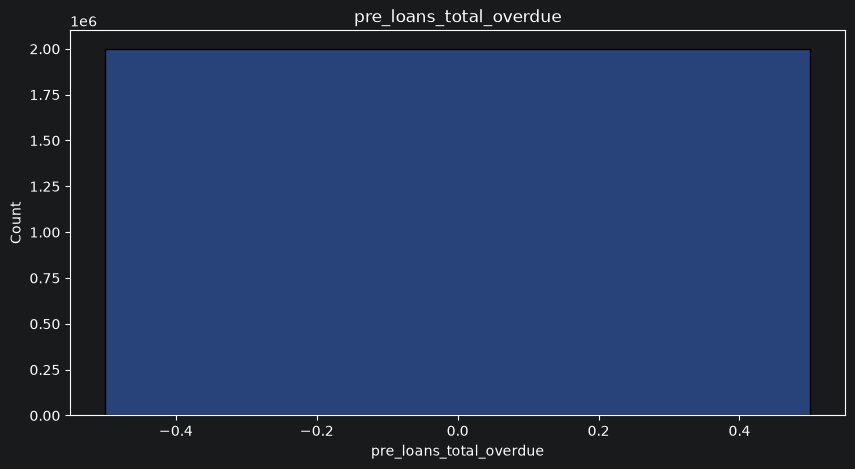

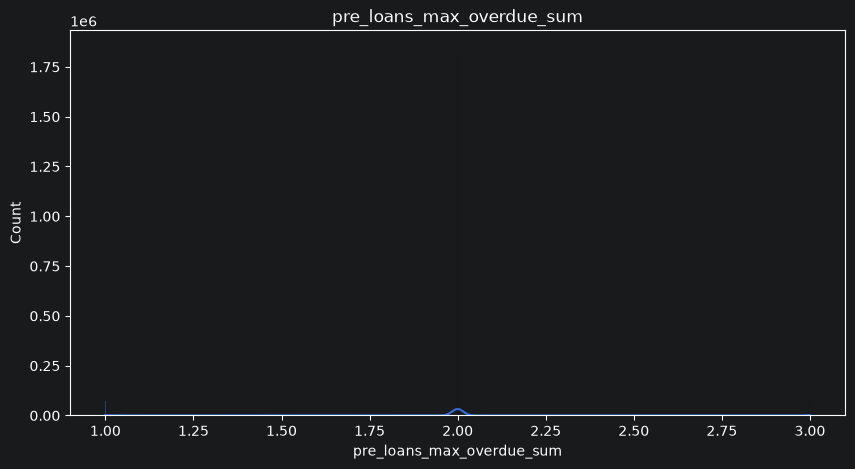

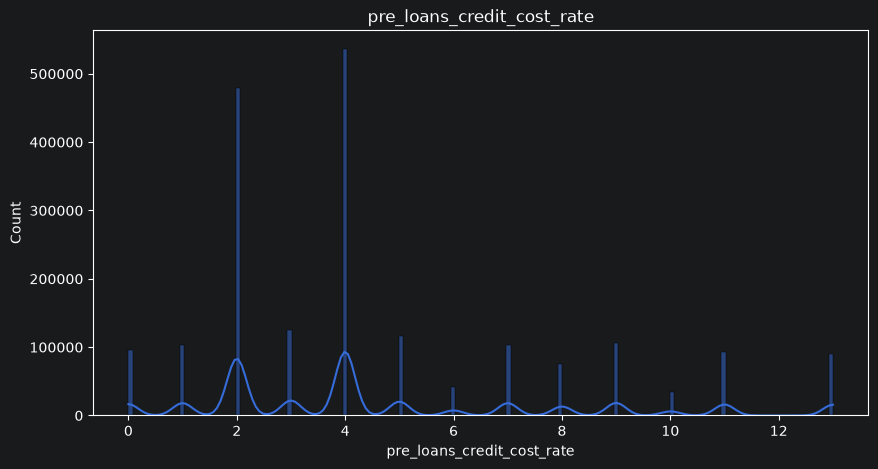

In [14]:
feature_distribution(df= data, features=numerical_features, categorical=False)

### Categorical features

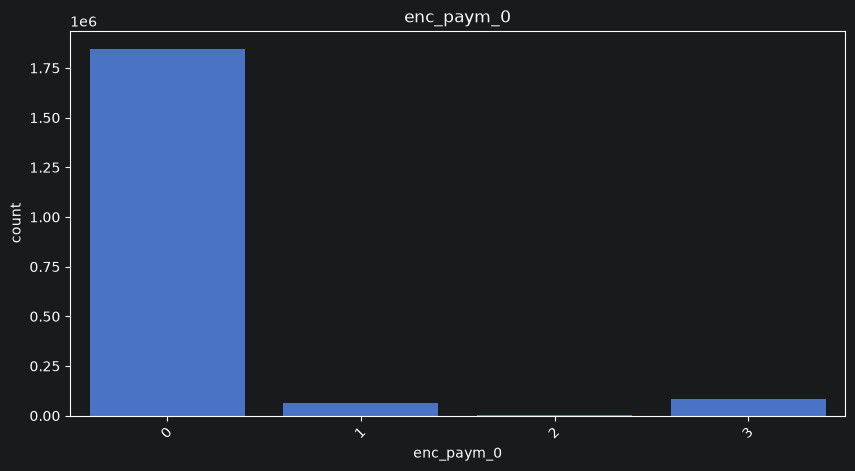

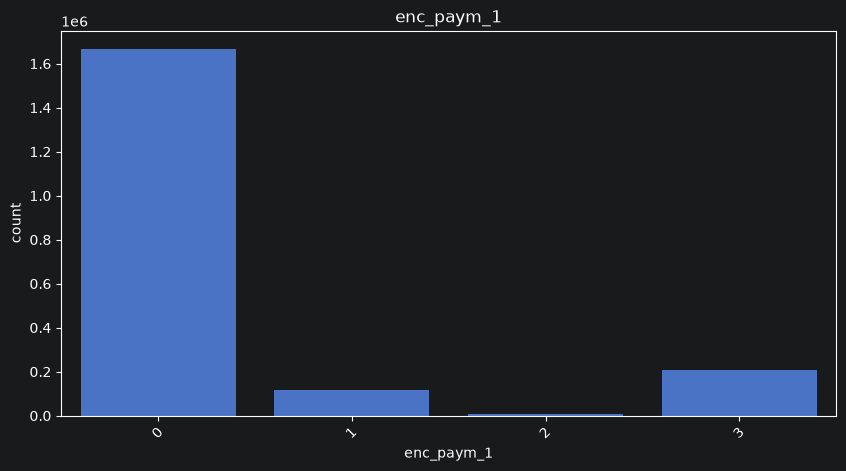

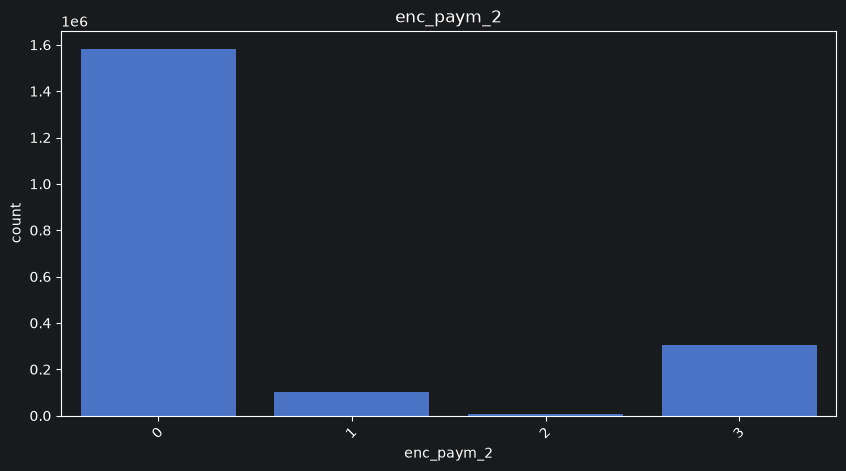

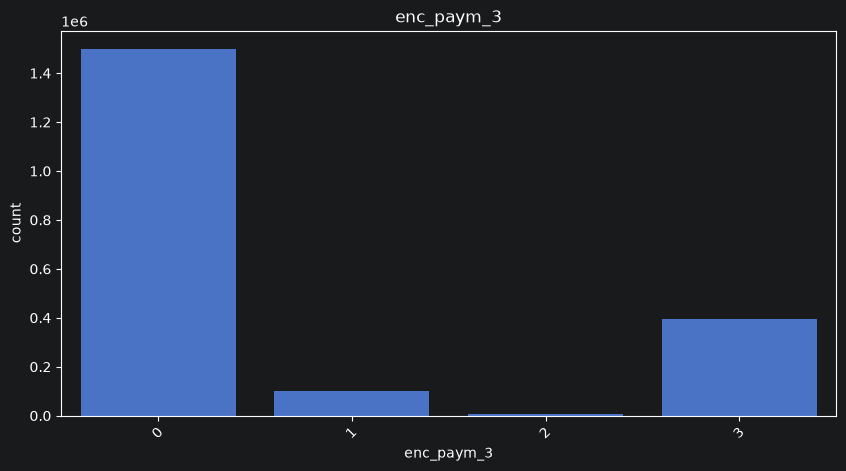

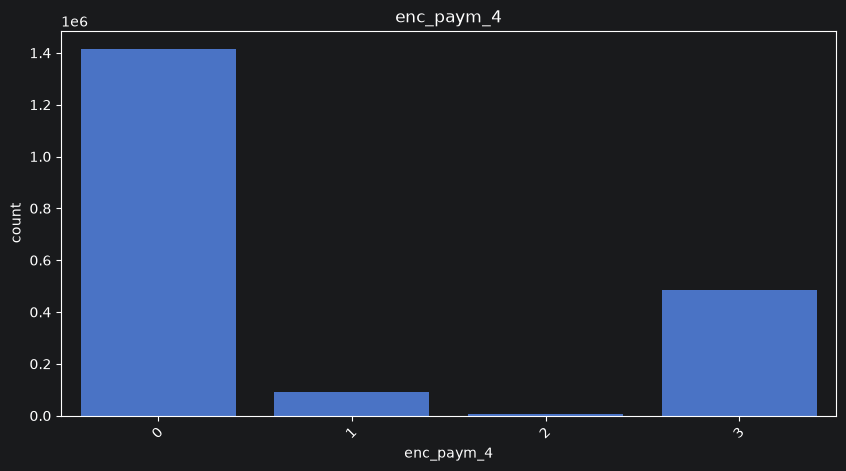

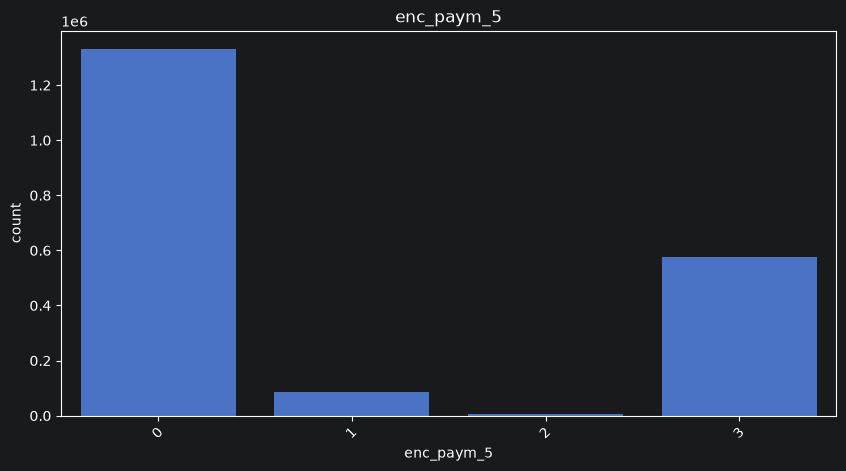

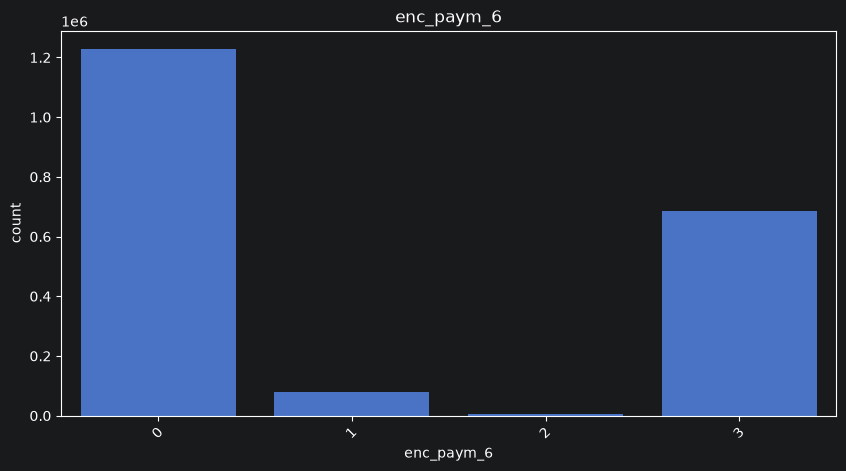

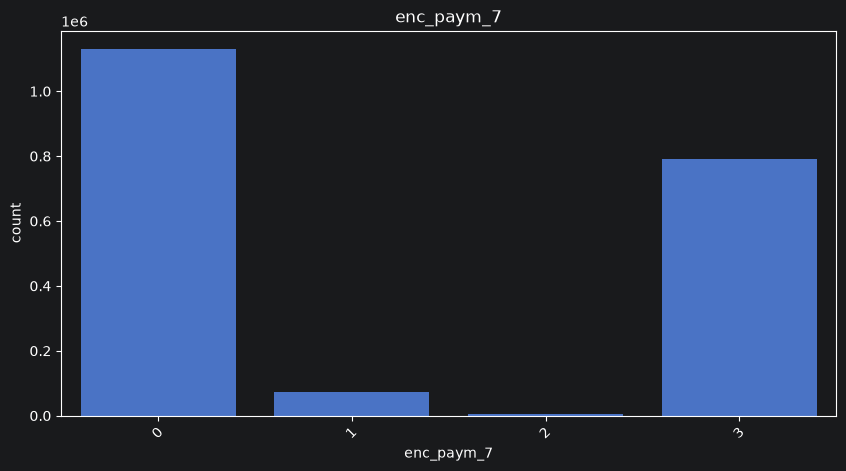

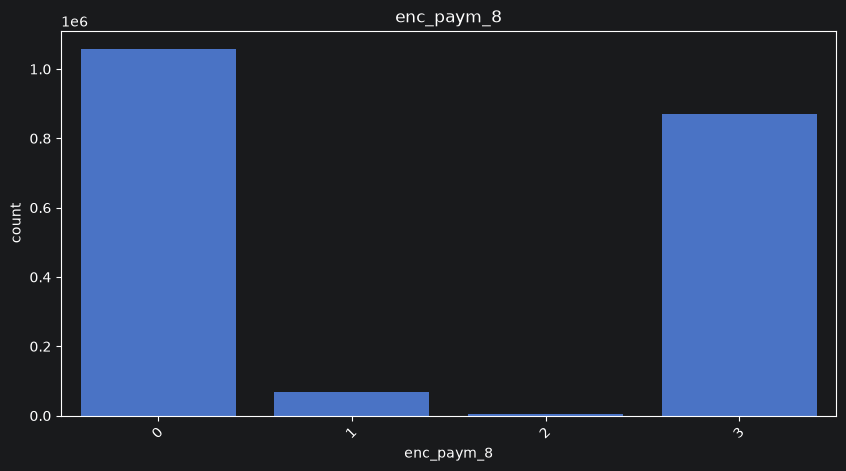

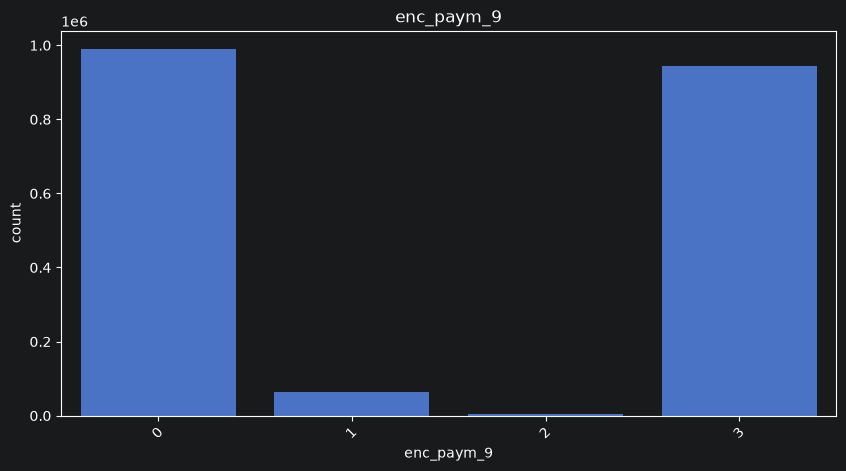

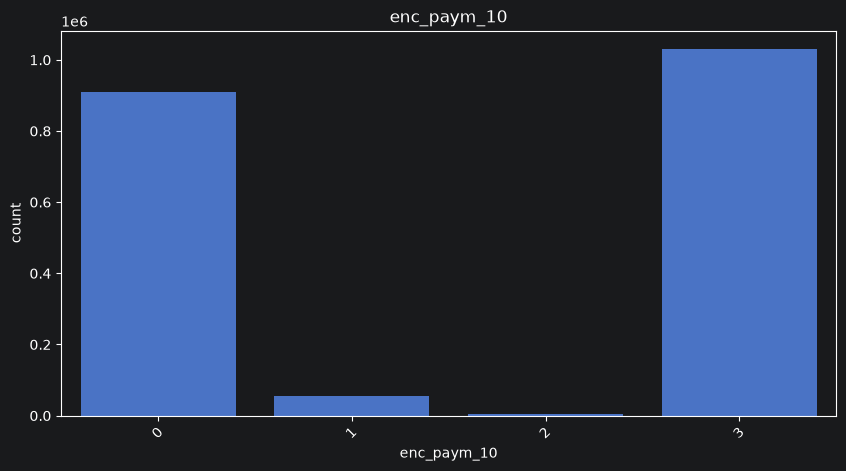

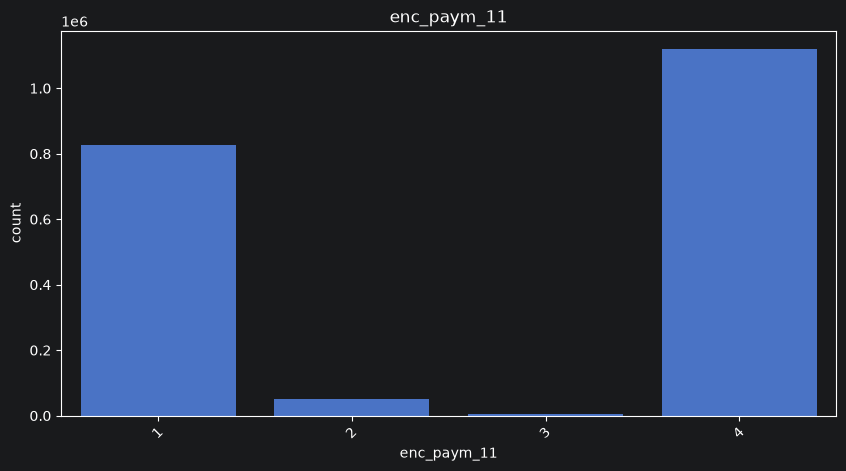

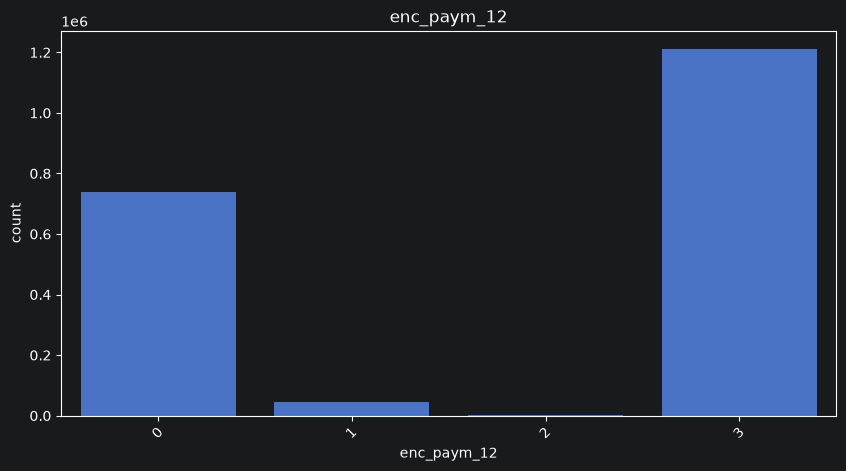

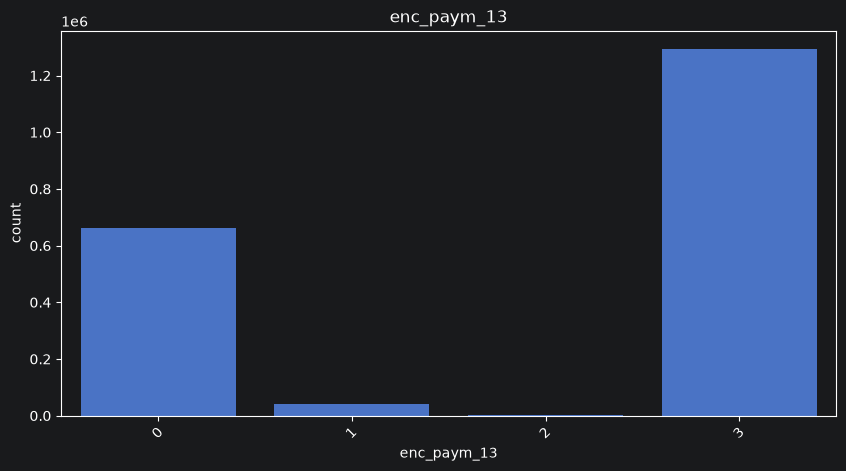

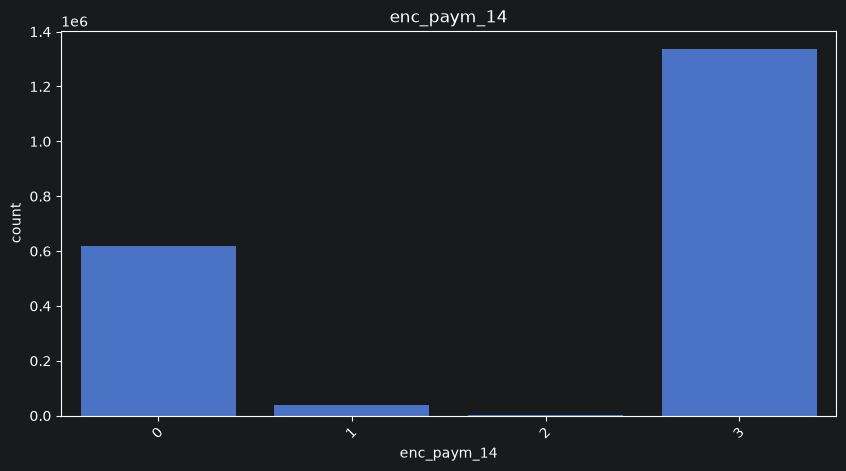

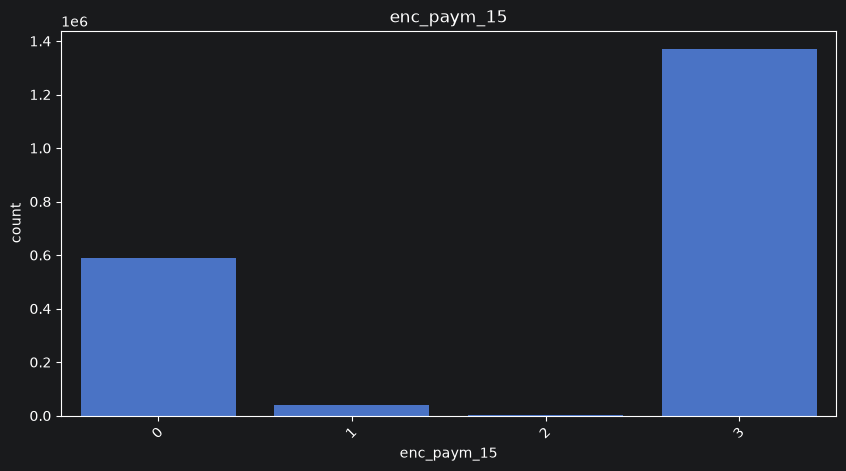

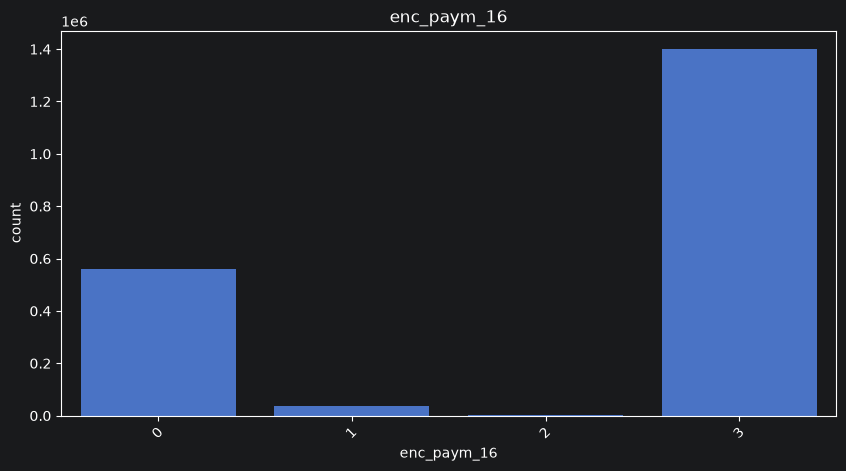

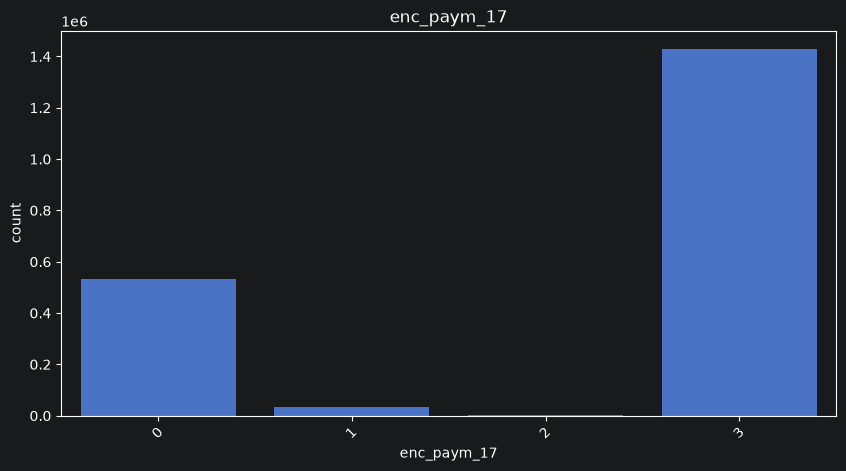

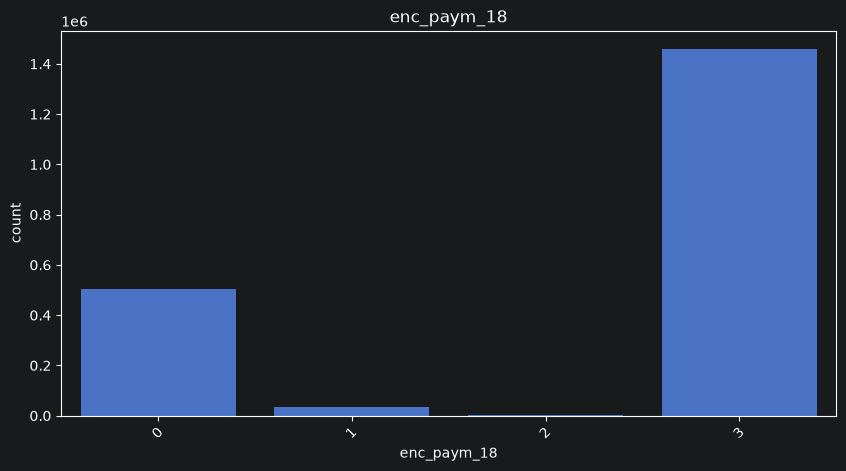

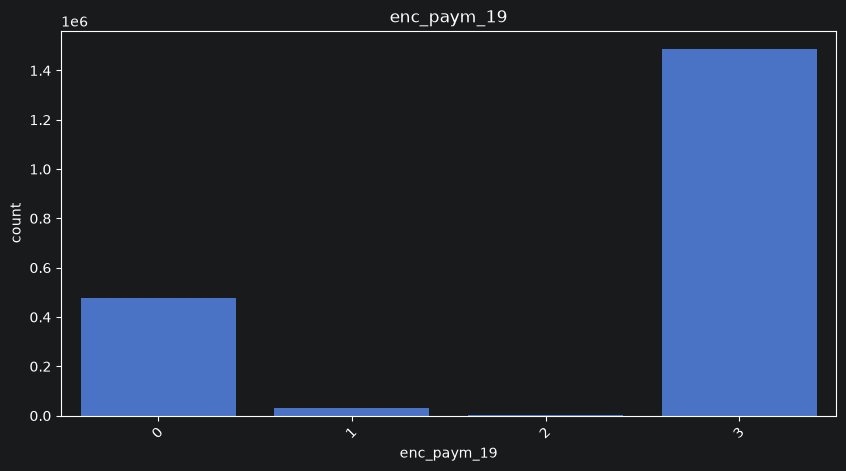

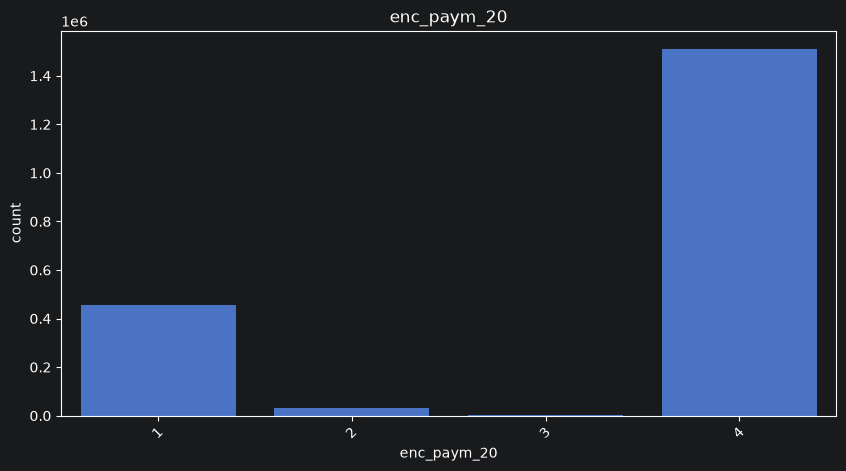

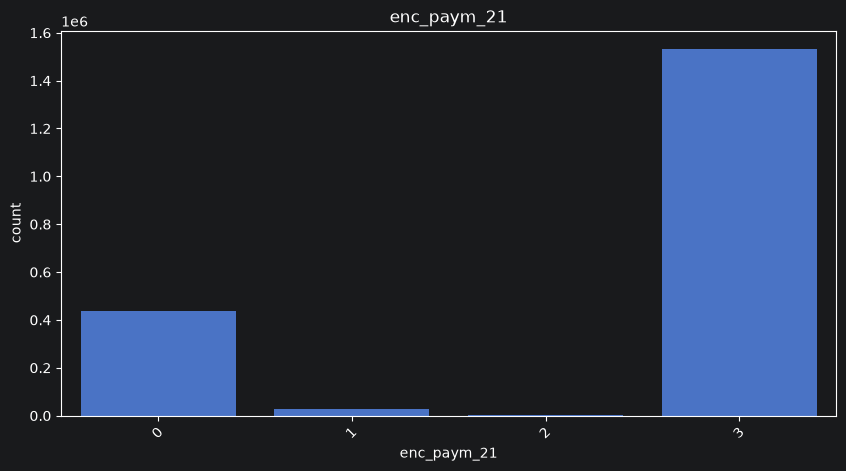

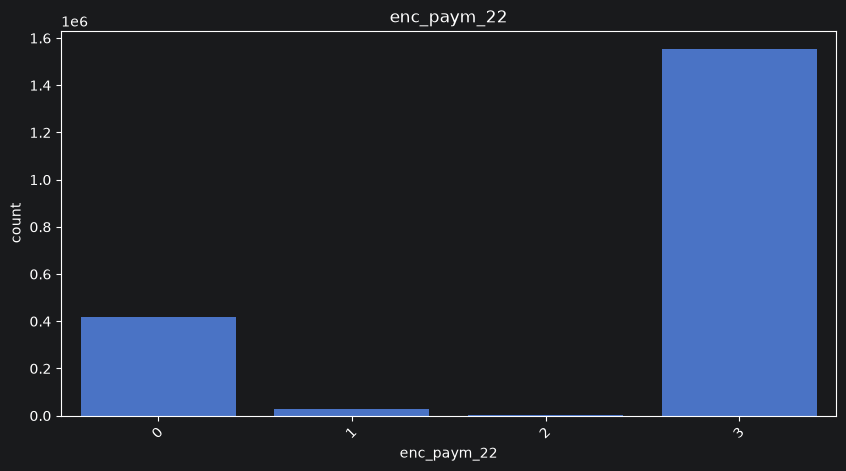

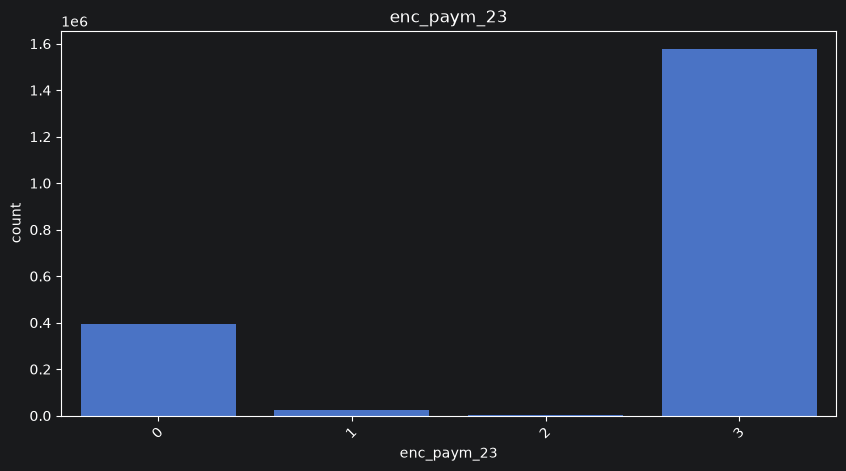

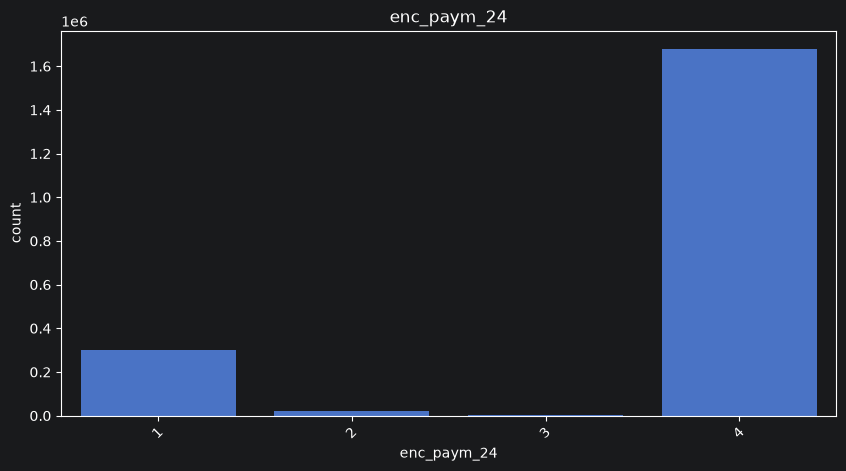

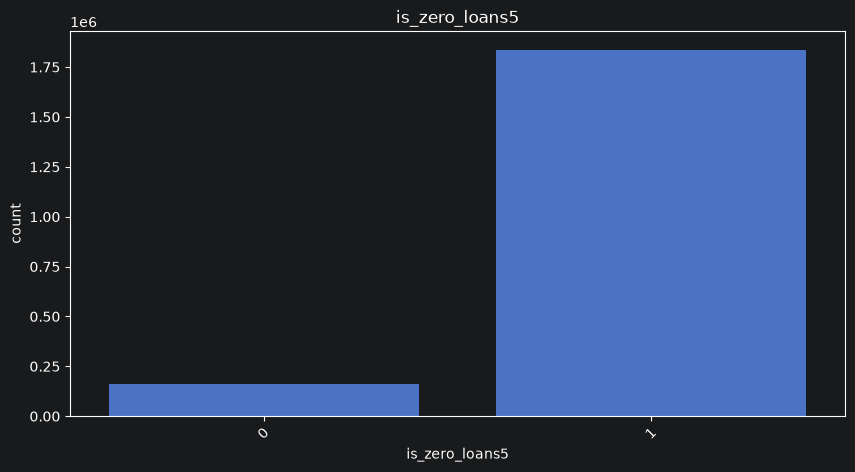

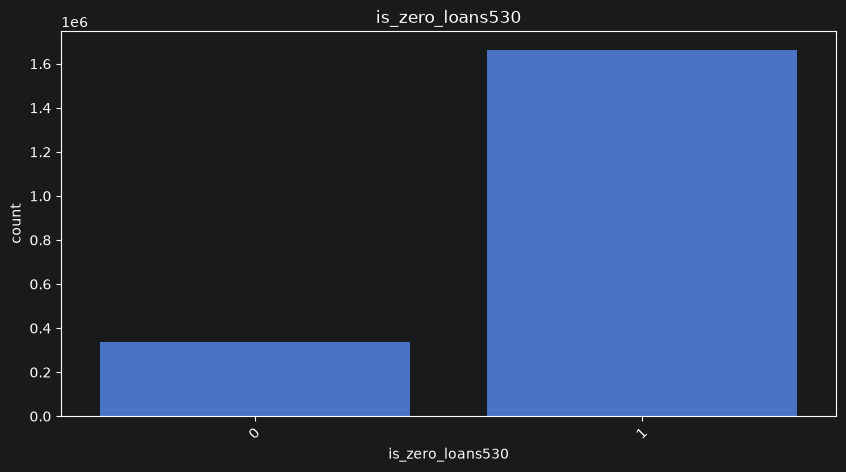

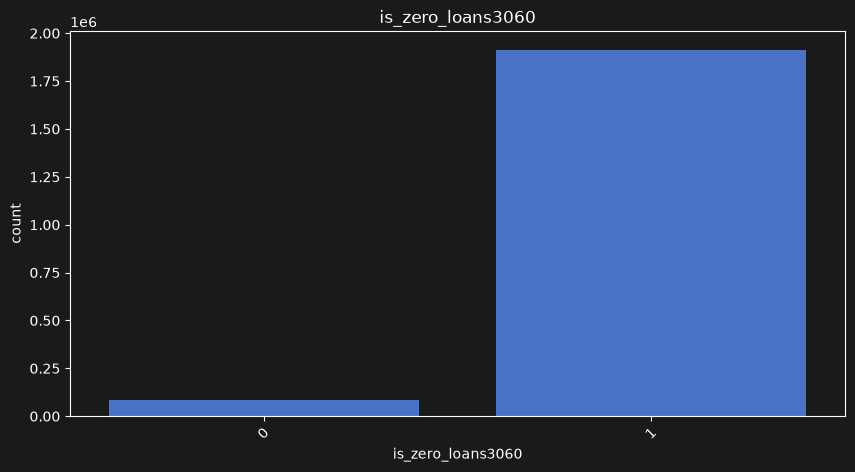

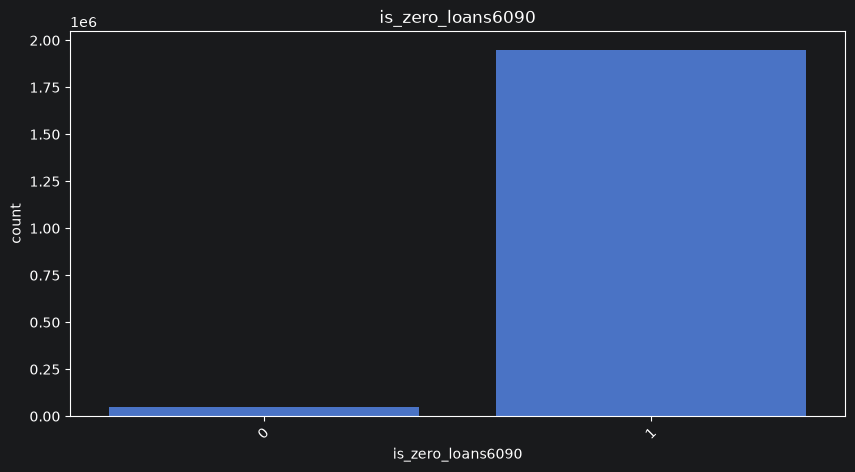

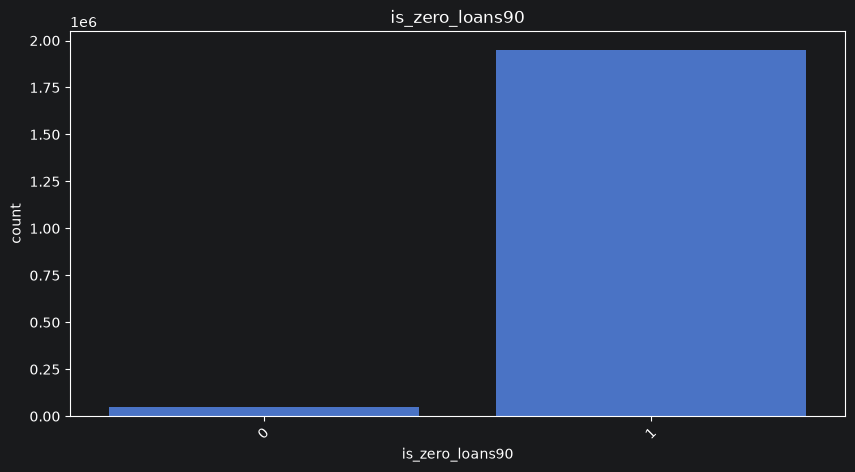

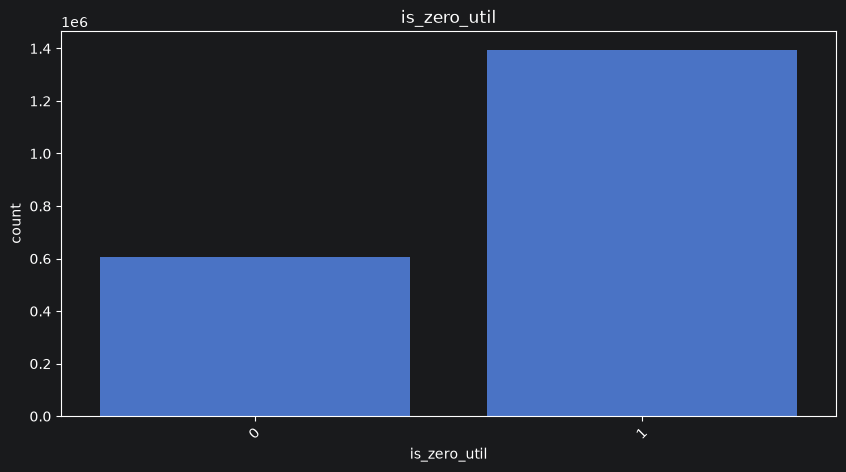

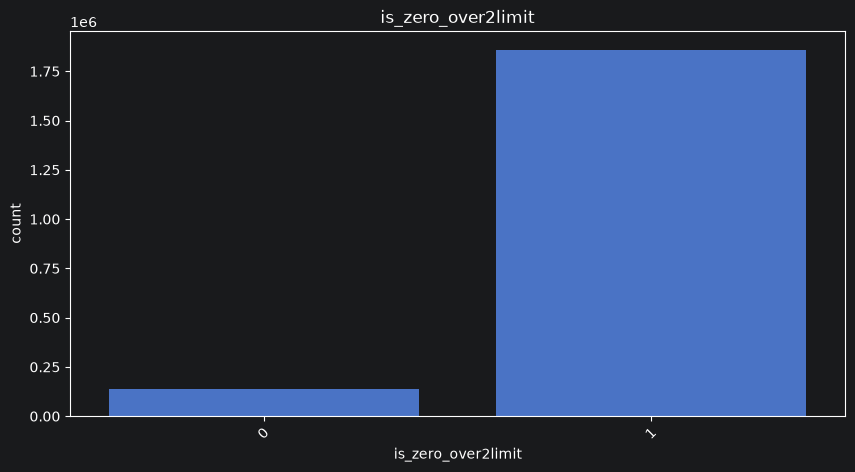

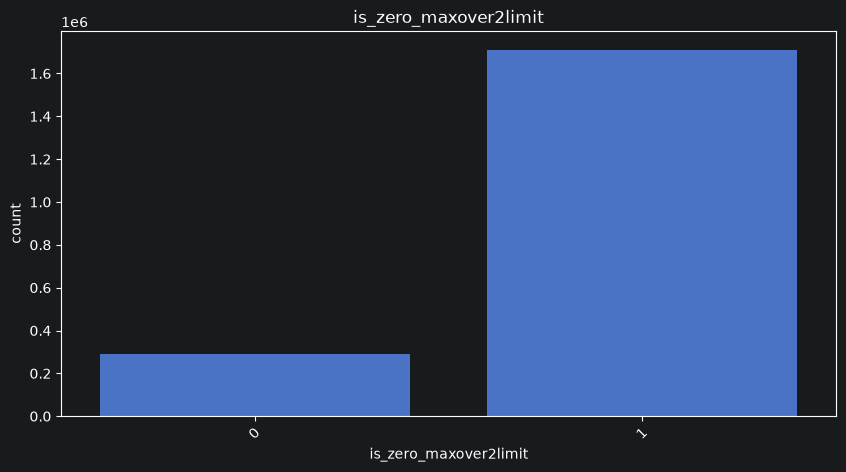

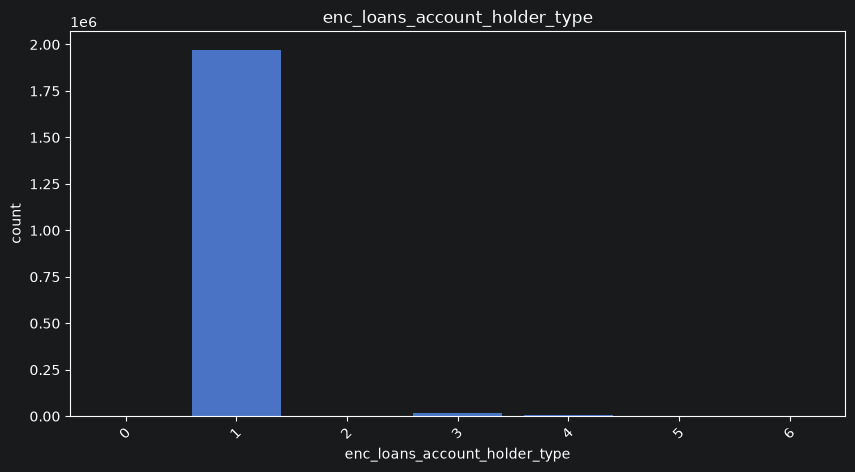

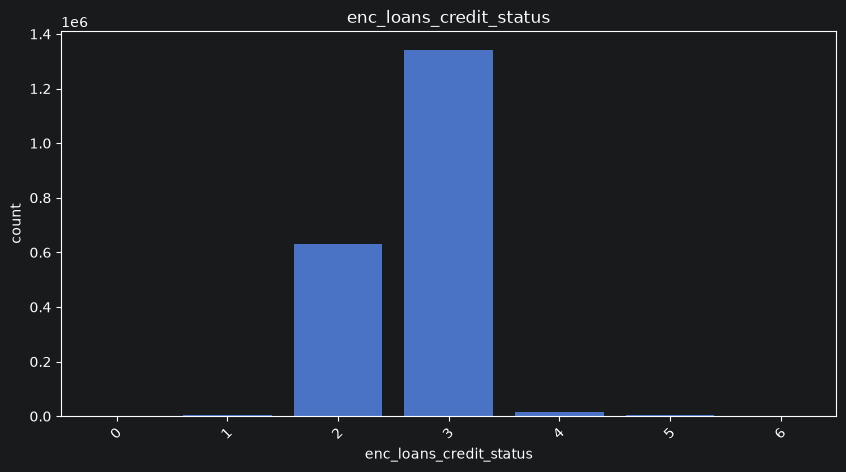

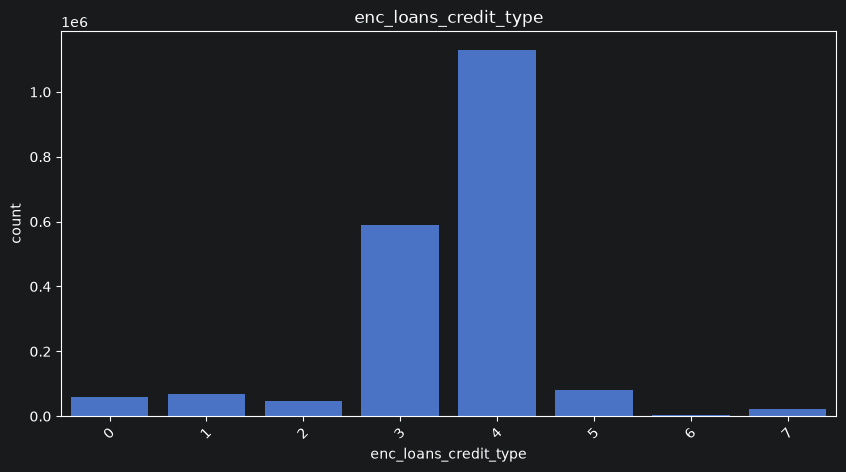

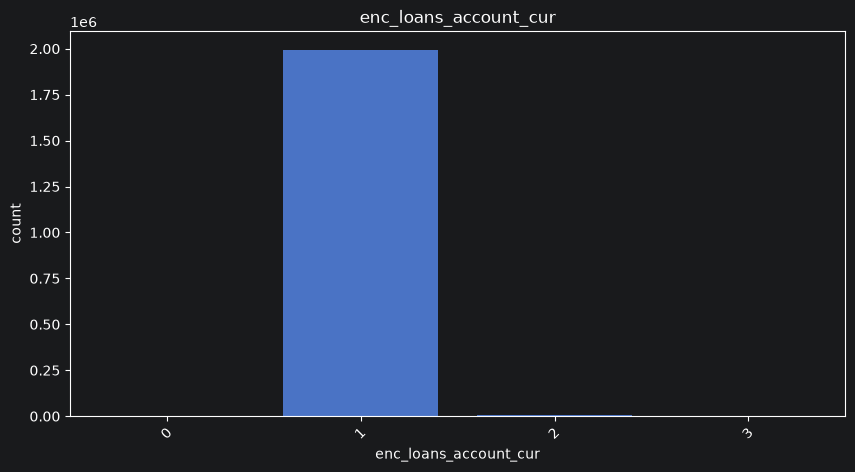

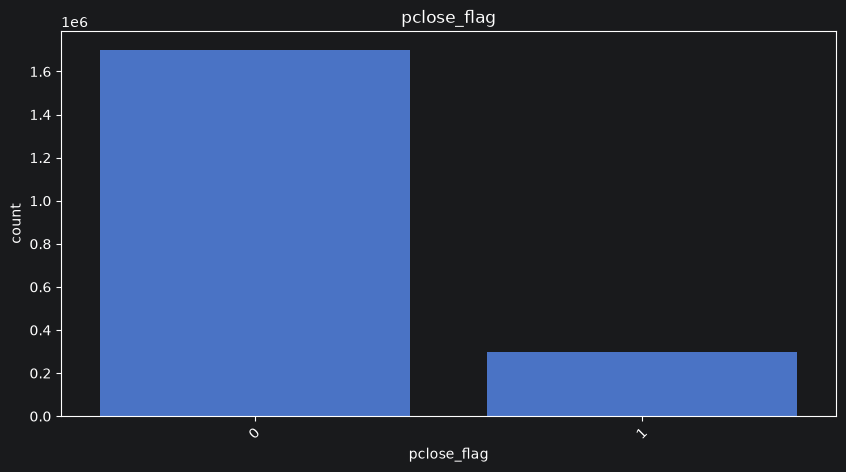

In [17]:
feature_distribution(df=data, features=categorical_features, categorical=True)